> ⚠️ **Before Running:** Update the dataset path below to point to your Google Drive folder.
> Dataset: [Download Here](https://drive.google.com/drive/folders/14dp4kEdV9k6esJs0tGTNb3AKFF6d-s9I?usp=sharing)
> Place it in your Google Drive under: `MyDrive/GAN_ART_IMAGES/Images/`

In [6]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install dominate visdom pillow

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.23 MiB | 31.82 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix/pytorch-CycleGAN-and-pix2pix
Looking in indexes: https://download.pytorch.org/whl/cu118


In [8]:
# Alternative Manual Installation (if Conda fails)
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install dominate visdom

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118


In [9]:
# Step 3: Download pretrained painting models (true GAN adversarial)
!bash ./scripts/download_cyclegan_model.sh style_monet
!bash ./scripts/download_cyclegan_model.sh style_vangogh
!bash ./scripts/download_cyclegan_model.sh style_cezanne
!bash ./scripts/download_cyclegan_model.sh style_ukiyoe

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2025-12-28 10:48:32--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  66.7MB/s    in 0.7s    

2025-12-28 10:48:33 (66.7 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]

Note: 

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
!python test.py \
  --dataroot /content/drive/MyDrive/GAN_ART_IMAGES \
  --model test \
  --dataset_mode single \
  --name style_vangogh_pretrained \
  --netG resnet_9blocks \
  --norm instance \
  --no_dropout \
  --phase test \
  --preprocess none \
  --load_size 256 \
  --crop_size 256 \
  --num_test 50  # or whatever limit you want

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/drive/MyDrive/GAN_ART_IMAGES	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256      

In [17]:
!ls ./results/style_vangogh_pretrained/test_latest/images/ | wc -l

100


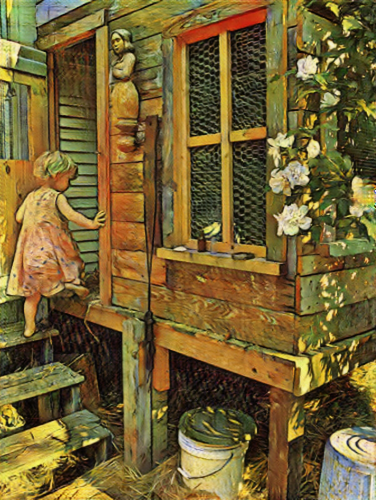

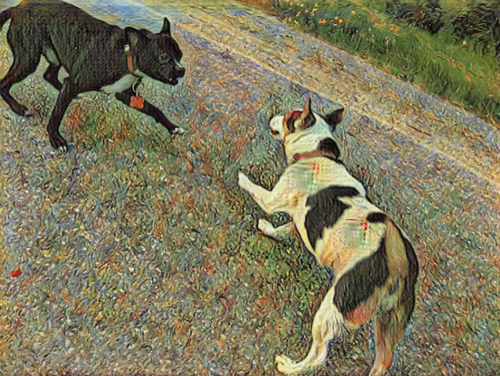

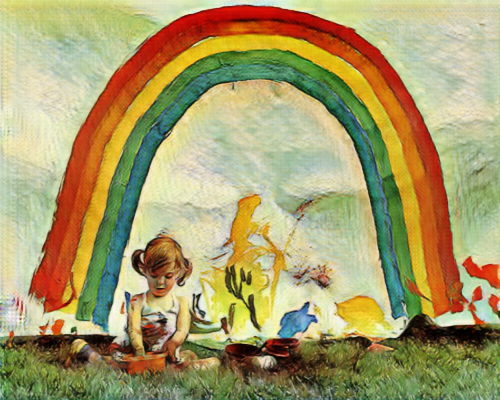

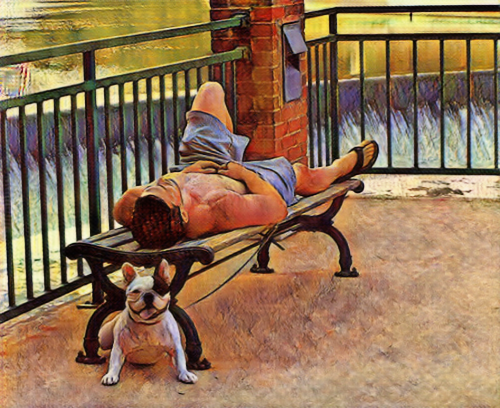

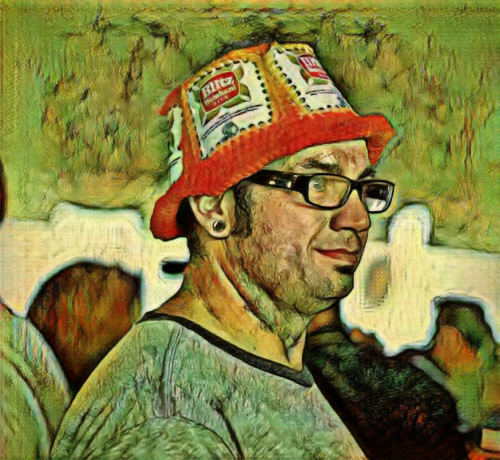

In [18]:
from IPython.display import Image, display
import os
results_dir = './results/style_vangogh_pretrained/test_latest/images/'
fake_images = sorted([f for f in os.listdir(results_dir) if f.endswith('_fake.png')])
for img in fake_images[:5]:  # Show first 5 styled results
    display(Image(os.path.join(results_dir, img)))